# Online Classification
- Logistic Regression on Stationary and Evolving Gaussian Datasets 
- online prequential evaluation with fading accuracy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

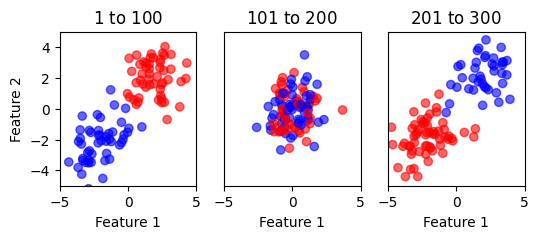

In [31]:
def generate_evolving_data(n_samples=1000):
    """Generate evolving Gaussian data"""
    X = []
    y = []
    for i in range(n_samples):
        alpha = i / n_samples
        # notice that the mean evolves over time (alpha depends on i)
        mean_a = -3 + 6 * alpha  # from -1 to +1
        mean_b = 3 - 6 * alpha   # from +1 to -1
        # random class choice
        if np.random.rand() < 0.5:
            X.append(np.random.randn(2) + mean_a)
            y.append(0)
        else:
            X.append(np.random.randn(2) + mean_b)
            y.append(1)
    return np.array(X), np.array(y)

def plot_evolving_data():
    X, y = generate_evolving_data(300)
    chunk_size = 100

    plt.figure(figsize=(6, 2))
    for i in range(0, len(X), chunk_size):
        plt.subplot(1, 3, i // chunk_size + 1)
        plt.title(f"${i+1}$ to ${i+chunk_size}$")
        plt.xlim(-5, 5)
        plt.ylim(-5, 5)
        plt.scatter(X[i:i+chunk_size, 0], X[i:i+chunk_size, 1], c=y[i:i+chunk_size], cmap='bwr', alpha=0.6, vmin=0, vmax=1)
        plt.xlabel("Feature 1")
        if i == 0:
            plt.ylabel("Feature 2")
        else:
            plt.yticks([])

plot_evolving_data()

# Logistic Regression

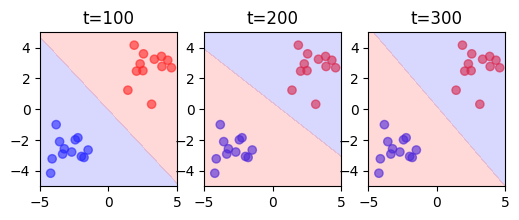

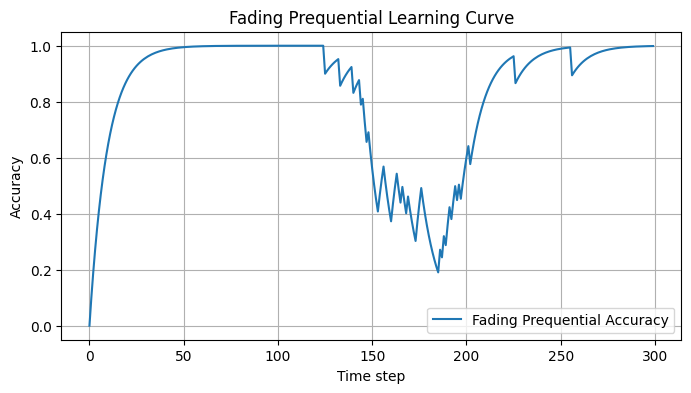

In [30]:
class LogisticRegression:
    def __init__(self, lr=0.1):
        self.lr = lr
        self.weights = None
        self.bias = None

    def partial_fit(self, X, y):
        # init the weights at the first iteration
        if self.weights is None:
            # notice that we need to do it here because we do not know X.shape during the __init__
            self.weights = np.zeros(X.shape[0])
            self.bias = 0

        # compute output logits
        linear_model = np.dot(self.weights, X) + self.bias
        # compute output probabilities
        y_predicted = self._sigmoid(linear_model)

        # gradients
        dw = (y_predicted - y) * X
        db = (y_predicted - y)

        # sgd step - descent in the gradient direction
        self.weights -= self.lr * dw
        self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        return np.where(y_predicted > 0.5, 1, 0)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

# Prequential training with periodic visualizations and fading accuracy
def prequential_evaluation():
    X, y = generate_evolving_data(300)
    model = LogisticRegression(lr=0.1)

    accuracy_history = []
    X_seen, y_seen = [], []
    fading_accuracy = 0.0
    fading_factor = 0.9
    checkpoints = [99, 199, 299]
    figid = 0

    plt.figure(figsize=(6, 2))
    for i in range(len(X)):
        x_i = X[i].reshape(2)
        y_i = y[i]

        if model.weights is not None:
            y_pred = model.predict(x_i)
            fading_accuracy = fading_factor * fading_accuracy + (1 - fading_factor) * (y_pred == y_i)
        else:
            fading_accuracy = 0

        accuracy_history.append(fading_accuracy)

        model.partial_fit(x_i, y_i)
        X_seen.append(x_i)
        y_seen.append(y_i)

        if i in checkpoints:
            figid += 1
            plt.subplot(1, 3, figid)
            plt.title(f"t={i+1}")
            plt.xlim(-5, 5)
            plt.ylim(-5, 5)
            plt.scatter(*zip(*X_seen[:25]), c=y_seen[:25], cmap='bwr', alpha=0.6, vmin=0, vmax=1)
            if model.weights is not None:
                xx, yy = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
                grid = np.c_[xx.ravel(), yy.ravel()]
                zz = np.dot(grid, model.weights) + model.bias
                zz = 1 / (1 + np.exp(-zz))
                zz = zz.reshape(xx.shape)
                plt.contourf(xx, yy, zz, levels=[0, 0.5, 1], alpha=0.3, cmap='bwr')
            # plt.show()

    # Plot learning curve at the end
    plt.figure(figsize=(8, 4))
    plt.plot(accuracy_history, label='Fading Prequential Accuracy')
    plt.xlabel("Time step")
    plt.ylabel("Accuracy")
    plt.title("Fading Prequential Learning Curve")
    plt.grid(True)
    plt.legend()

prequential_evaluation()
